### AGGLOMERATIVE CLUSTERING

In [2]:
import numpy as np
import pandas as pd

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

##### Loading datasets

In [3]:
data = pd.read_csv("../../../data/preprocessed/preprocessed_dataset.csv")
y = data["expression"].astype("category").cat.codes

datasets = {
    "Scaled dataset": "../../../data/reduced/X_scaled.npy",
    "PCA dataset": "../../../data/reduced/X_pca.npy"
}

##### Agglomerative clustering

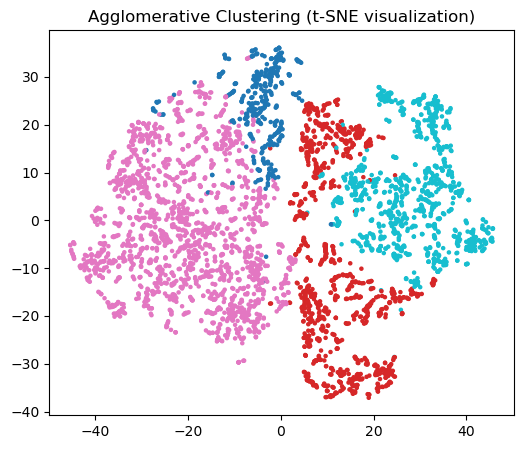

,Dataset,Algorithm,K,Silhouette,Davies_Bouldin,ARI,NMI
0,Scaled dataset,Agglomerative,4,0.269685,1.498653,0.048089,0.131993
1,PCA dataset,Agglomerative,4,0.301666,1.468324,0.042857,0.125995


In [5]:
results = []

for dataset_name, X_data in datasets.items():
    X = np.load(X_data)

    # sampling to avoid O(n^2) explosion
    sample_size = 5000
    np.random.seed(42)
    sample_idx = np.random.choice(len(X), sample_size, replace=False)

    X = X[sample_idx]
    y_sample = y[sample_idx]

    k = 4
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X)

    row = {
        "Dataset": dataset_name,
        "Algorithm": "Agglomerative",
        "K": k,
        "Silhouette": silhouette_score(X, labels, sample_size=3000),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "ARI": adjusted_rand_score(y_sample, labels),
        "NMI": normalized_mutual_info_score(y_sample, labels)
    }
    results.append(row)

    if dataset_name == "PCA dataset":
        tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
        X_tsne = tsne.fit_transform(X)

        plt.figure(figsize=(6,5))
        plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap="tab10", s=5)
        plt.title("Agglomerative Clustering (t-SNE visualization)")
        plt.show()
        

results_df = pd.DataFrame(results)
results_df